# Assignment 3
### Due 9/23. Do four of five.

In [1]:
import pandas as pd
import numpy as np

1. 
- Open the NHANES (or Ames prices or college completion datasets, if you prefer)
- Find two categorical variables of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis like we did with police use of force, but always be aware of how dirty the data are)
- Compute a contingency table for your categorical $X$ and $Y$
- Discuss any interesting patterns (or lack of one) that you observe

In [3]:
nhanes = pd.read_csv("data/nhanes_data_17_18.csv")
nhanes_meta = pd.read_csv("data/nhanes_meta_17_18.csv")

/var/folders/wq/1s0gf8fd03j2tv622kv6k26w0000gn/T/ipykernel_74722/4154696686.py:1: DtypeWarning: Columns (142) have mixed types. Specify dtype option on import or set low_memory=False.
  nhanes = pd.read_csv("data/nhanes_data_17_18.csv")


In [ ]:
nhanes.columns
#GeneralHealthCondition:Y and TriedToQuitSmoking:X

Index(['SEQN', 'GeneralHealthCondition', 'EverBreastfedOrFedBreastmilk',
       'AgeStoppedBreastfeedingdays', 'AgeFirstFedFormuladays',
       'AgeStoppedReceivingFormuladays', 'AgeStartedOtherFoodbeverage',
       'AgeFirstFedMilkdays', 'TypeOfMilkFirstFedWholeMilk',
       'TypeOfMilkFirstFed2Milk',
       ...
       'DaysSmokedCigsDuringPast30Days', 'AvgCigarettesdayDuringPast30Days',
       'TriedToQuitSmoking', 'TimesStoppedSmokingCigarettes',
       'HowLongWereYouAbleToStopSmoking',
       'UnitOfMeasureDayweekmonthyear_2_SMQ',
       'CurrentSelfreportedHeightInches', 'CurrentSelfreportedWeightPounds',
       'TriedToLoseWeightInPastYear', 'TimesLost10LbsOrMoreToLoseWeight'],
      dtype='object', length=198)

In [ ]:
nhanes_meta.columns 

Index(['VariableNameLong', 'Variable', 'Type', 'Format', 'Informat', 'Label',
       'Source', 'VariableName', 'SASLabel', 'EnglishText', 'Target',
       'VariableNameLong_variable_df', 'Source_variable_df',
       'EnglishInstructions', 'HardEdits', 'Recoded', 'CustomRecoding',
       'nNonNA'],
      dtype='object')

In [26]:
len(nhanes[["GeneralHealthCondition", "TriedToQuitSmoking"]])

8366

In [ ]:
ghc_try = nhanes[["GeneralHealthCondition", "TriedToQuitSmoking"]].dropna()
ghc_try["GeneralHealthCondition"].unique()
len(ghc_try)
#massive difference

926

In [14]:
ct = pd.crosstab(ghc_try["GeneralHealthCondition"],
                 ghc_try["TriedToQuitSmoking"],
                 dropna=False)
ct

TriedToQuitSmoking,0.0,1.0
GeneralHealthCondition,,
Excellent,21,33
Fair or,127,152
Good,195,197
Poor?,21,22
Very good,78,80


In [23]:
pd.crosstab(
    ghc_try["GeneralHealthCondition"],
    ghc_try["TriedToQuitSmoking"],
    normalize="columns"
)

TriedToQuitSmoking,0.0,1.0
GeneralHealthCondition,,
Excellent,0.047511,0.068182
Fair or,0.287330,0.314050
Good,0.441176,0.407025
Poor?,0.047511,0.045455
Very good,0.176471,0.165289


In [21]:
(ghc_try["GeneralHealthCondition"] == "Excellent").sum() / len(ghc_try)

0.058315334773218146

I am pretty surprised that we dont see a greater skew in terms of health condition

I would expect those who have tried to quit to be healthier than those who haven't but there doesnt seem to be a significant difference in proportions (without doing any sort of testing)

2. 
- Open the NHANES dataset
- Find a categorical and numeric variable of interest (there are 198, and short descriptions are given in the `nhanes_meta_17_18.csv` file). Investigate their missing values (you don't have to focus on missing values for this analysis, but always be aware of them)
- Make descriptive tables and grouped kernel density plots to represent the variation in your numeric $Y$ conditional on your categorical $X$
- Discuss any interesting patterns (or lack of one) that you observe

In [27]:
ghc_avg = nhanes[["GeneralHealthCondition", "AvgCigarettesdayDuringPast30Days"]]

len(ghc_avg)

8366

In [ ]:
ghc_avg = ghc_avg.dropna()  

len(ghc_avg)
#also a massive difference

914

In [31]:
import matplotlib.pyplot as plt

X = "AvgCigarettesdayDuringPast30Days"      
Y = "GeneralHealthCondition"

order = ["Excellent","Very good","Good","Fair","Poor"]
if set(order).issuperset(ghc_avg[Y].unique()):
    ghc_avg[Y] = pd.Categorical(ghc_avg[Y], categories=order, ordered=True)


g = ghc_avg.groupby(Y)[X]
desc = pd.DataFrame({
    "n": g.size(),
    "mean": g.mean(),
    "std": g.std(),
    "median": g.median(),
    "q25": g.quantile(.25),
    "q75": g.quantile(.75),
    "iqr": g.quantile(.75) - g.quantile(.25),
})
desc

,n,mean,std,median,q25,q75,iqr
GeneralHealthCondition,,,,,,,
Excellent,54,8.129630,6.704114,5.5,3.0,10.0,7.0
Fair or,278,11.794964,8.115438,10.0,6.0,20.0,14.0
Good,385,10.919481,8.010167,10.0,5.0,20.0,15.0
Poor?,42,17.547619,12.869329,17.5,8.5,20.0,11.5
Very good,155,14.406452,62.086105,8.0,4.0,15.0,11.0


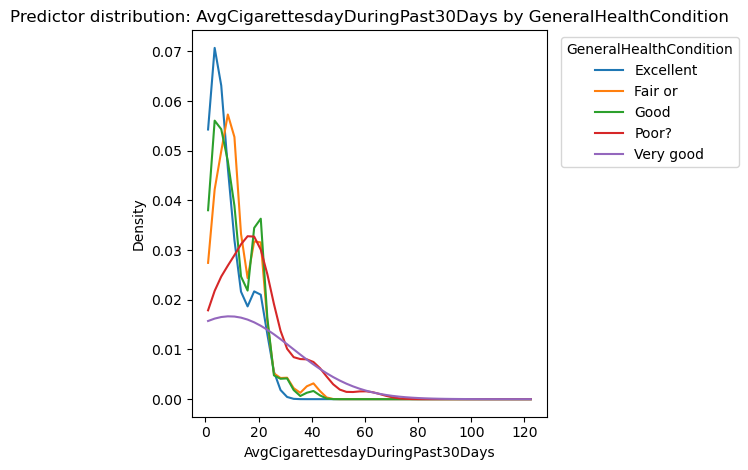

In [34]:
from scipy.stats import gaussian_kde

lo, hi = ghc_avg[X].quantile([0.001, 0.999])
xs = np.linspace(lo, hi, 50)

plt.figure()
for level, sub in ghc_avg.groupby(Y):
    arr = sub[X].to_numpy()
    kde = gaussian_kde(arr)
    plt.plot(xs, kde(xs), label=str(level))

plt.xlabel(X); plt.ylabel("Density")
plt.title(f"Predictor distribution: {X} by {Y}")
plt.legend(title=Y, bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


Excellent has looks to have the sharpest decreasing slope, whereas poor has the slowest. This makes sense
It is interesting how very good health is in line with poor

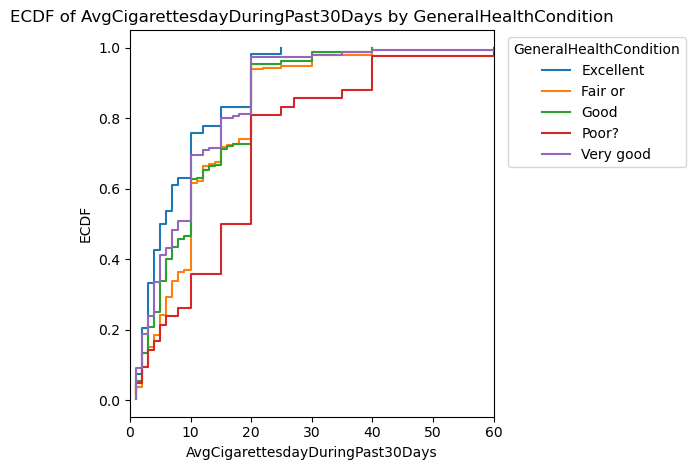

In [36]:
def ecdf(a):
    v = np.sort(a); y = np.arange(1, v.size+1)/v.size; return v, y

plt.figure()
for level, sub in ghc_avg.groupby(Y):
    v, yv = ecdf(sub[X].to_numpy())
    plt.step(v, yv, where="post", label=str(level))
plt.xlabel(X); plt.ylabel("ECDF")
plt.xlim(0, 60)
plt.title(f"ECDF of {X} by {Y}")
plt.legend(title=Y, bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


This looks more like what I would expect, with poor GHC having more of their population smoke more cigarettes, and excellent GHV having the fastest rising slope in opposition to this

3. 
We showed that the mean and median could be discovered by minimizing various kinds of loss functions; this is what machine learning is. To make a prediction $\hat{y}(z)$ of $Y$ when $X=z$, minimize the mean squared error:
$$
MSE(\hat{y}(z)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(z) \right\rbrace^2 \frac{1}{h}k\left(\frac{z-x_i}{h}\right)
$$
Show that the solution to this problem is the LCLS/Naradaya-Watson estimator.

In [ ]:
# I put my answer to this question in github since it was a picture and mac sucks at screenshots

4. 
- Write a class or set of functions that implement the LCLS/Naradaya-Watson estimator, using the Silverman plug-in estimate for the conditioning variable $X$ as the bandwidth.
- From one of the course data sets, find two numeric variables of interest, analyze their relationship with the the LCLS/Naradaya-Watson estimator, and discuss your results.

In [49]:
def gaussian_kernel(u):
    return np.exp(-0.5 * u*u) / np.sqrt(2*np.pi)

def silverman_bandwidth(x):
    x = np.asarray(x)
    n  = x.size
    s  = np.std(x, ddof=1)
    iqr = np.subtract(*np.percentile(x, [75, 25]))
    sigma = min(s, iqr/1.34) if iqr > 0 else s
    return 1.06 * sigma * n ** (-1/5)

def nw_predict(x_train, y_train, x_eval, h=None, kernel=gaussian_kernel, eps=1e-12):
    x_train = np.asarray(x_train).reshape(-1)
    y_train = np.asarray(y_train).reshape(-1)
    x_eval  = np.asarray(x_eval).reshape(-1)
    if h is None:
        h = silverman_bandwidth(x_train)
    y_hat = np.empty_like(x_eval, dtype=float)
    for j, x0 in enumerate(x_eval):
        u = (x_train - x0) / h
        w = kernel(u)
        s = w.sum()
        y_hat[j] = (w @ y_train) / (s + eps)
    return y_hat


In [64]:
ti_avg = nhanes[['Glycohemoglobin', 'AvgCigarettesdayDuringPast30Days']].dropna()

[  5.   2.  15.  25.  20.  10.  20.  10.  25.  10.  10.   3.  12.  10.
   4.   4.   1.  10.  20.  10.   5.   5.  20.  20.  30.  20.  10.   6.
   1.  10.   5.  10.   8.  20.  40.  10.   5.  10.  10.   1.  10.   5.
   6.   6.   8.   2.  20.  12.  20.   1.  10.  20.   4.   6.   3.  20.
   5.   6.  20.  10.   6.   1.  20.  15.   4.   7.  13.  40.  10.  20.
   5.   8.  20.  20.   2.   6.  20.  10.  20.  15.  10.  40.   2.  20.
   2.   2.  20.  15.   1.   3.  10.  10.   5.  10.   2.   5.  20.  16.
  20.   8.   6.  10.   2.   7.  15.  10.  15.   1.   2.  20.   1.  15.
   2. 999.  20.   6.  20.   8.  35.  18.  10.   4.   6.   3.  20.  10.
   7.   6.  40.  20.  10.  20.  20.   4.  10.   7.  15.   7.  12.  10.
  12.  10.   7.   2.   3.   6.  10.  12.   4.   2.  20.  15.  10.  10.
  16.  20.   3.  10.  10.   2.  20.  10.  10.   4.   7.  10.  20.   5.
   6.  10.  40.  20.  10.  10.  15.  20.   3.  20.   6.   1.  12.  12.
   3.  10.   2.   5.  20.  20.  10.  15.  10.  40.   3.   2.   5.   3.
  20. 

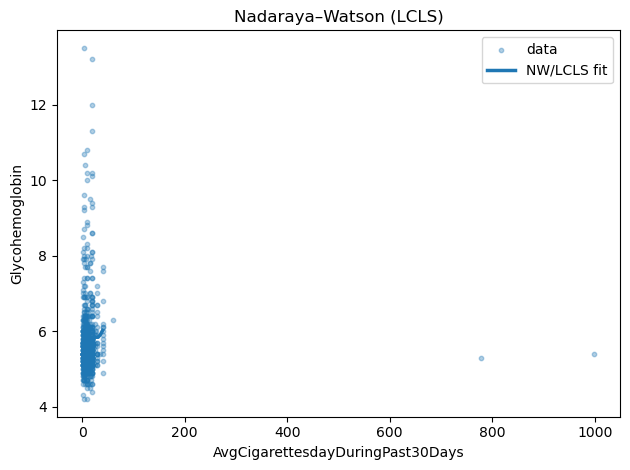

In [75]:
x = ti_avg['AvgCigarettesdayDuringPast30Days'].to_numpy()
print(x)
y = ti_avg['Glycohemoglobin'].to_numpy()
print(y)
# ---- set evaluation grid over X ----
x_lo, x_hi = np.quantile(x, [.01, 0.99])
x_grid = np.linspace(x_lo, x_hi, 10)
print(x_lo, x_hi)
# ---- fit NW with Silverman bandwidth on X ----
h = silverman_bandwidth(x)
y_grid = nw_predict(x, y, x_grid, h=h)

print(f"Silverman bandwidth for X : h = {h:.4g}")

# ---- quick plot: scatter + smoother ----
plt.figure()
plt.scatter(x, y, s=10, alpha=0.35, label="data")
plt.plot(x_grid, y_grid, linewidth=2.5, label="NW/LCLS fit")
plt.xlabel("AvgCigarettesdayDuringPast30Days"); plt.ylabel("Glycohemoglobin")
plt.title(f"Nadaraya–Watson (LCLS)")
plt.legend(); plt.tight_layout(); plt.show()

#someone lied about smoking 1000 cigarettes

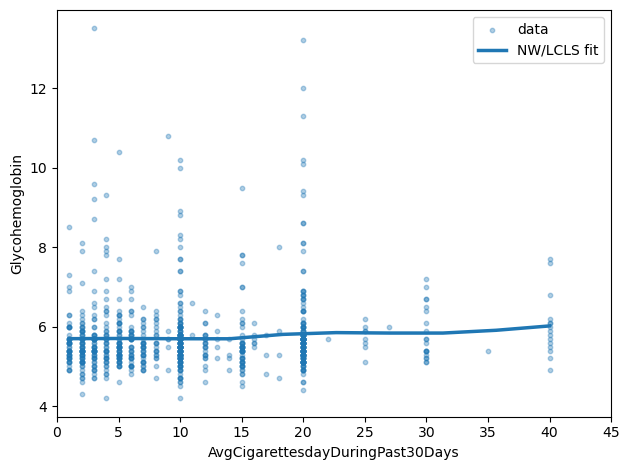

In [77]:
#fixed to ignore weird outlier

plt.scatter(x, y, s=10, alpha=0.35, label="data")
plt.plot(x_grid, y_grid, lw=2.5, label="NW/LCLS fit")
plt.xlim(0, 45)
plt.xlabel("AvgCigarettesdayDuringPast30Days"); plt.ylabel("Glycohemoglobin")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
#the relationship looks to be slightly positive, but not very strong.


5. 
- In any of the available data sets, investigate the relationships between pairs of variables $(X,Y)$ with a scatterplot and CEF (for example, price on area)
- Is this relationship plausibly causal, or are there missing variables that might explain at least part of the relationship between your variables? These can be "conceptual" rather than "practical"; for example, 'talent' or 'grit' probably explain education outcomes, but are almost impossible to measure. We are asking whether there are hypothetical **threats to causal identification** of the effect of $X$ on $Y$.
- Explain how, regardless of the threat to causal identification, you can still use your model to predict $Y$ given $X$, as long as you don't intervene in the system to control the outcome